# Ceridwen spectroscopy test: LEGA-C M1_210210

- fit the same passive galaxy using LEGA-C spectroscopy
- resolve absorption features with the alpha-enhanced C3K_HR grid

## 1. Imports and reproducibility

- use Ceridwen's alpha-enhanced stellar population model
- record one seed for every stochastic calculation

In [1]:
import os
import time
from datetime import UTC, datetime
from pathlib import Path

import astropy.units as u
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from scipy.special import softmax
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

from ceridwen.cosmology import age_gyr
from ceridwen.csp import CSPBasis_afe
from ceridwen.fit import load_result_h5, write_result_h5
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import Spectrum
from ceridwen.sampler import run_sampler
from ceridwen.sampler.nested import BlackJAXNestedSamplerAdapter
from ceridwen.sampler.priors import Uniform
from ceridwen.ssps import SSPDataAfe, fetch_grid

jax.config.update("jax_enable_x64", True)

SEED = 20260811
NOTEBOOK_STARTED_AT = datetime.now(UTC)
NOTEBOOK_START_TIME = time.perf_counter()
JAX_DEVICES = jax.devices()
GPU_AVAILABLE = any(device.platform == "gpu" for device in JAX_DEVICES)
QUICK_TEST = os.environ.get("CERIDWEN_NOTEBOOK_QUICK") == "1"
SPECTRUM_MODES = {"full", "features"}
SPECTRUM_MODE = os.environ.get("CERIDWEN_SPECTRUM_MODE", "full")
if SPECTRUM_MODE not in SPECTRUM_MODES:
    choices = ", ".join(sorted(SPECTRUM_MODES))
    raise ValueError(f"Unknown spectrum mode {SPECTRUM_MODE!r}; choose {choices}")
RUN_PROFILE = "quick" if QUICK_TEST else ("gpu-full" if GPU_AVAILABLE else "cpu-trial")
DEFAULT_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", DEFAULT_PROJECT_ROOT))
RESULTS_ROOT = Path(os.environ.get("CERIDWEN_RESULTS_ROOT", PROJECT_ROOT / "results"))
RUN_ID = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")
RESULT_DIR = (
    RESULTS_ROOT
    / f"ceridwen_test_spectra_{SPECTRUM_MODE}_{RUN_PROFILE}_{RUN_ID}"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"JAX devices: {JAX_DEVICES}")
print(f"run profile: {RUN_PROFILE}")
print(f"spectrum mode: {SPECTRUM_MODE}")
print(f"project root: {PROJECT_ROOT}")
print(f"result directory: {RESULT_DIR}")

JAX devices: [CudaDevice(id=0)]
run profile: gpu-full
spectrum mode: features
project root: /workspace
result directory: /workspace/notebooks/ceridwen_test_spectra_features_gpu-full_20260825T174826Z


## 2. Load the matched LEGA-C catalogues

- reuse the photometric match defining notebook 06's sample

In [2]:
LEGAC_PATH = PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz"
PHOT_PATH = (
    PROJECT_ROOT
    / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
)
SPECTRA_DIR = PROJECT_ROOT / "data/raw/legac_dr2/sp"

In [3]:
legac = Table.read(LEGAC_PATH)
phot = Table.read(PHOT_PATH)

assert len(legac) == 1988
assert len(np.unique(phot["LEGAC_INDEX"])) == len(phot)
assert np.max(phot["MATCH_SEP_ARCSEC"]) < 1.0
assert "uJy" in phot["Fipap3"].unit.to_string()

print(f"LEGA-C DR2 rows: {len(legac)}")
print(f"COSMOS2015 counterparts: {len(phot)}")
print(f"maximum retained separation: {np.max(phot['MATCH_SEP_ARCSEC']):.3f} arcsec")

LEGA-C DR2 rows: 1988
COSMOS2015 counterparts: 1982
maximum retained separation: 0.925 arcsec


## 3. Rebuild the passive sample

- require primary scientific-use LEGA-C spectra
- apply earlier NUVrJ and emission-line cuts
- require clean photometric footprint flags

In [4]:
legac_frame = legac.to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac_frame[text_column] = legac_frame[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot_frame = phot.to_pandas().set_index("LEGAC_INDEX")
phot_columns = [
    "Area", "Sat", "Cfl", "Deep", "Flag", "E(B-V)", "NUVMag", "RMag",
    "JMag", "Fuap3", "e_Fuap3", "FBap3", "e_FBap3", "FVap3", "e_FVap3",
    "Frap3", "e_Frap3", "Fipap3", "e_Fipap3", "Fzppap3", "e_Fzppap3",
    "FYap3", "e_FYap3", "FJap3", "e_FJap3", "FHap3", "e_FHap3",
    "FKsap3", "e_FKsap3", "F3.6um", "e_F3.6um", "F4.5um", "e_F4.5um",
]
parent = legac_frame.join(phot_frame[phot_columns], how="inner")

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
)
valid_rest_magnitudes = (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1)
parent = parent[quality & valid_rest_magnitudes].copy()

nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"]
nuvrj = (nuv_r > 3 * r_j + 1) & (nuv_r > 3.1)
photometric_passive = parent[nuvrj]

oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()]
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (
    weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]
).abs()
bona_fide_passive = weak_oii[
    ~((oii_significance >= 3) | (oiii_significance >= 3))
]

clean_photometry = (
    (bona_fide_passive["Area"] == 0)
    & (bona_fide_passive["Sat"] == 0)
    & (bona_fide_passive["Cfl"] == 1)
    & (bona_fide_passive["Flag"] == 0)
)
usable_passive = bona_fide_passive[clean_photometry]

selection_counts = pd.Series(
    {
        "matched primary spectra": len(parent),
        "NUVrJ passive": len(photometric_passive),
        "weak [OII]": len(weak_oii),
        "bona-fide passive": len(bona_fide_passive),
        "clean twelve-band photometry": len(usable_passive),
    }
)
display(selection_counts.to_frame("count"))

,count
matched primary spectra,1328
NUVrJ passive,609
weak [OII],454
bona-fide passive,349
clean twelve-band photometry,194


## 4. Load the same high-S/N test galaxy

- fix redshift and velocity dispersion from LEGA-C

In [5]:
def load_spectrum(filename):
    if isinstance(filename, bytes):
        filename = filename.decode()
    with fits.open(SPECTRA_DIR / filename) as hdulist:
        spectrum = hdulist[1].data
        instrument_resolution = float(hdulist[0].header["SPEC_RES"])
    wave, flux, error, quality_flag = (
        spectrum[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
    )
    good = (quality_flag == 0) & (error > 0) & np.isfinite(flux)
    return wave, flux, error, good, instrument_resolution


target_rows = usable_passive[usable_passive["SPECT_ID"] == "M1_210210"]
assert len(target_rows) == 1
galaxy = target_rows.iloc[0]
wave_air, flux_dr2, error_dr2, good_pixel, instrument_fwhm_resolution = (
    load_spectrum(galaxy["Filename"])
)

z_catalog = float(galaxy["z"])
observed_break = 4000 * (1 + z_catalog)
assert wave_air[good_pixel].min() < observed_break < wave_air[good_pixel].max()

print(f"{galaxy['SPECT_ID']}  z={galaxy['z']:.4f}")
print(f"catalogue S/N={galaxy['SN']:.1f}")
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
print(f"fixed sigma*={sigma_star:.1f} km/s")
print(f"instrument FWHM resolving power={instrument_fwhm_resolution:.0f}")
print(
    f"good spectral coverage: {wave_air[good_pixel].min():.0f}-"
    f"{wave_air[good_pixel].max():.0f} angstrom"
)

M1_210210  z=0.6542
catalogue S/N=62.2
fixed sigma*=259.5 km/s
instrument FWHM resolving power=2500
good spectral coverage: 6190-8633 angstrom


## 5. Load the alpha-enhanced stellar grid

- load the published Kroupa C3K high-resolution grid

In [6]:
grid_path = fetch_grid("amist_c3k_hr_krou_afe")
ssp = SSPDataAfe.load(grid_path)
ssp.display()

universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, universe_age])

assert ssp.ssp_flux.shape[0] == 5
assert np.all(np.isfinite(ssp.ssp_resolution))
assert lookback_template[-1] <= 10 ** float(ssp.ssp_lg_age_gyr.max())

print(f"catalogue-redshift universe age: {universe_age:.3f} Gyr")
print(f"SFH nodes: {lookback_template}")

SSPDataAfe
------------------------------------------------------------------
provenance
  isochrones (isoc_type)   : MIST v2.5 (aMIST, alpha-variable)
  spectral library         : C3K v2.3 high-res (c3k_hr, vt=10 km/s)
  IMF (imf_type)           : 2
  FSPS version             : —
  schema version           : 2.1
  recorded wave_min/max    : 100.0 / 99595854.863
  build kwargs             : {'source_fits': 'ssp_final_mistv2.5_c3kv2.3vt10allfal_250722.fits', 'provider': 'M. J. Park (2025-07-22)', 'zsun_reference': 0.0185, 'feh_to_logZ': 'log10 Z = [Fe/H] + log10(Zsun)', 'imf_name': 'Kroupa'}
grids
  [alpha/Fe]               :    5 pts   [-0.2  0.   0.2  0.4  0.6]
  metallicity  log10 Z     :   13 pts   [-4.233, -1.233]  (absolute TOTAL Z, NOT Z/Zsun, NOT [Fe/H])
  age          log10(Gyr)  :  107 pts   [-4.000, +1.300]  = [0.0001, 20] Gyr
  wavelength   Angstrom    : 10992 pts   [100.0, 99595854.9]
  flux (n_afe,n_met,n_age,n_wave): (5, 13, 107, 10992)  [L_sun Hz^-1 M_sun^-1]  float64  5

catalogue-redshift universe age: 7.566 Gyr
SFH nodes: [0.         0.03       0.1        0.3        1.         3.
 5.         7.56620799]


## 6. Build the native-resolution spectrum

- select full-spectrum or LEGA-C feature pixels
- apply catalogue resolution and automatic library correction
- remove invalid, emission-line, and telluric pixels
- compact arrays before model projection and likelihood
- retain two masked endpoints for identical smoothing
- initialize Ceridwen's sampled calibration floor at three percent

Spectrum (spectrum)
  ndata         : 1926
  ndof          : 1924
  wavelength    : 5801.9 – 9501.9 Å
  resolution    : 2500.0 (fwhm convention)
  smoothtype    : R
  sigma_losvd   : 259.5 km/s
  logify        : False
  calibration   : none
  sky           : none
  noise_floor   : 0.0000
  noise model   : none
  masked pixels : 2 / 1926

  i              λ [Å]            flux               σ   mask
  -----------------------------------------------------------
  0            5801.91      0.0000e+00      1.0000e+00  False
  1            6370.86      9.2092e-29      3.1990e-30   True
  2            6371.46      9.3163e-29      2.8303e-30   True
  3            6372.06      9.6121e-29      2.8274e-30   True
  4            6372.66      9.8815e-29      3.7358e-30   True
  5            6373.26      9.3978e-29      2.8340e-30   True
  6            6373.86      9.3654e-29      2.8399e-30   True
  7            6374.46      9.0529e-29      3.9902e-30   True
  8            6375.06      9.2335e-29  

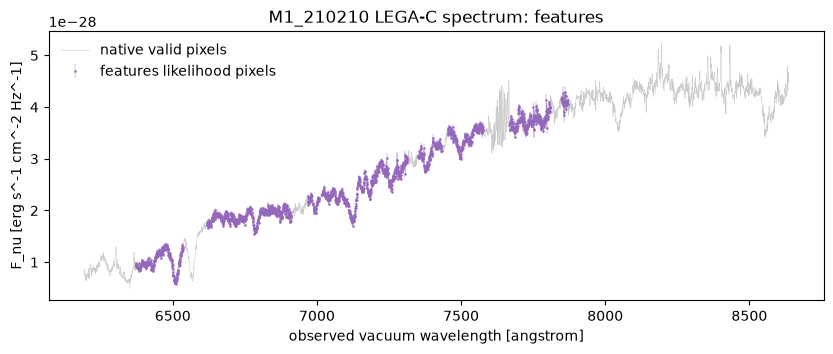

In [7]:
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA
SPECTRUM_CALIBRATION_INIT = 0.03
REST_EMISSION_LINES = [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]
LEGAC_FEATURE_BANDS_AIR = {
    "CN1": ((4080.125, 4117.625), (4142.125, 4177.125), (4244.125, 4284.125)),
    "CN2": ((4083.875, 4096.375), (4142.125, 4177.125), (4244.125, 4284.125)),
    "Ca4227": ((4211.0, 4219.75), (4222.25, 4234.75), (4241.0, 4251.0)),
    "G4300": ((4266.375, 4282.625), (4281.375, 4316.375), (4318.875, 4335.125)),
    "Fe4383": ((4359.125, 4370.375), (4369.125, 4420.375), (4442.875, 4455.375)),
    "Ca4455": ((4445.875, 4454.625), (4452.125, 4474.625), (4477.125, 4492.125)),
    "Fe4531": ((4504.25, 4514.25), (4514.25, 4559.25), (4560.5, 4579.25)),
    "C2_4668": ((4611.5, 4630.25), (4634.0, 4720.25), (4742.75, 4756.5)),
    "HdA": ((4041.6, 4079.75), (4083.5, 4122.25), (4128.5, 4161.0)),
    "HgA": ((4283.5, 4319.75), (4319.75, 4363.5), (4367.25, 4419.75)),
    "HdF": ((4057.25, 4088.5), (4091.0, 4112.25), (4114.75, 4137.25)),
    "HgF": ((4283.5, 4319.75), (4331.25, 4352.25), (4354.75, 4384.75)),
    "D4000n": ((3850.0, 3950.0), (4000.0, 4100.0)),
}


def flam_to_fnu_cgs(values, wavelength):
    f_lambda = values * DR2_FLUX_UNIT
    return f_lambda.to_value(
        u.erg / u.s / u.cm**2 / u.Hz,
        equivalencies=u.spectral_density(wavelength * u.AA),
    )


wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
spectrum_native = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
uncertainty_native = flam_to_fnu_cgs(error_dr2, wave_vacuum)
native_valid = (
    good_pixel
    & np.isfinite(spectrum_native)
    & np.isfinite(uncertainty_native)
    & (uncertainty_native > 0)
)
native_flux = np.nan_to_num(spectrum_native, nan=0.0)
native_uncertainty = np.where(
    native_valid, uncertainty_native, 1.0
)
native_spectrum_obs = Spectrum(
    wavelength=wave_vacuum,
    flux=native_flux,
    uncertainty=native_uncertainty,
    mask=native_valid,
    resolution=instrument_fwhm_resolution,
    smoothtype="R",
    res_convention="fwhm",
    sigma_losvd=sigma_star,
    name="native_spectrum",
)
native_spectrum_obs.mask_lines(
    REST_EMISSION_LINES,
    dv=1500.0,
    zred=z_catalog,
)
telluric_vacuum = air_to_vac(np.array([7590.0, 7660.0]) * u.AA).to_value(u.AA)
native_spectrum_obs.mask_wavelength_range(*telluric_vacuum)
native_fit_mask = np.asarray(native_spectrum_obs.mask)

rest_wave_air = wave_air / (1 + z_catalog)
feature_pixel_mask = np.zeros(rest_wave_air.shape, dtype=bool)
for windows in LEGAC_FEATURE_BANDS_AIR.values():
    for lower, upper in windows:
        feature_pixel_mask |= (rest_wave_air >= lower) & (rest_wave_air <= upper)

fit_pixel_mask = native_fit_mask.copy()
if SPECTRUM_MODE == "features":
    fit_pixel_mask &= feature_pixel_mask

projection_anchor_indices = np.array([0, len(wave_vacuum) - 1])
compact_indices = np.unique(
    np.concatenate((np.flatnonzero(fit_pixel_mask), projection_anchor_indices))
)
spectrum_wave = wave_vacuum[compact_indices]
spectrum_flux = native_flux[compact_indices]
spectrum_uncertainty = native_uncertainty[compact_indices]
compact_likelihood_mask = fit_pixel_mask[compact_indices]
spectrum_obs = Spectrum(
    wavelength=spectrum_wave,
    flux=spectrum_flux,
    uncertainty=spectrum_uncertainty,
    mask=compact_likelihood_mask,
    resolution=instrument_fwhm_resolution,
    smoothtype="R",
    res_convention="fwhm",
    sigma_losvd=sigma_star,
    name="spectrum",
)
spectrum_mask = np.asarray(spectrum_obs.mask)

grid_wave = np.asarray(ssp.ssp_wave)
grid_resolving_power = np.median(grid_wave[:-1] / np.diff(grid_wave))
assert np.isclose(grid_resolving_power, 6000.0, rtol=0.01)
assert spectrum_obs.ndof == fit_pixel_mask.sum()
assert spectrum_obs.ndata <= spectrum_obs.ndof + 2
assert spectrum_wave[0] == wave_vacuum[0]
assert spectrum_wave[-1] == wave_vacuum[-1]
assert np.all(np.diff(spectrum_wave) > 0)

spectrum_obs.display()
print(f"native good pixels: {good_pixel.sum()}")
print(f"median grid pixel resolving power: R={grid_resolving_power:.0f}")
print("library resolution: schema-2.1 automatic curve")
print(f"native LEGA-C pixels: {len(wave_vacuum)}")
print(f"full fitted pixels after exclusions: {native_fit_mask.sum()}")
print(f"{SPECTRUM_MODE} likelihood pixels: {spectrum_obs.ndof}")
print(f"compact projection pixels: {spectrum_obs.ndata}")
if SPECTRUM_MODE == "features":
    print(f"feature definitions: {', '.join(LEGAC_FEATURE_BANDS_AIR)}")
print(f"fixed stellar velocity dispersion: {sigma_star:.1f} km/s")
print("calibration-floor prior: 1%-10%; initialized at 3%")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(
    wave_vacuum[native_valid],
    native_flux[native_valid],
    lw=0.4,
    color="0.8",
    label="native valid pixels",
)
ax.errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=spectrum_uncertainty[spectrum_mask],
    fmt=".",
    ms=1.5,
    lw=0.3,
    color="tab:purple",
    label=f"{SPECTRUM_MODE} likelihood pixels",
)
ax.set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="F_nu [erg s^-1 cm^-2 Hz^-1]",
)
ax.set_title(f"M1_210210 LEGA-C spectrum: {SPECTRUM_MODE}")
ax.legend(frameon=False)
plt.show()

## 7. Define the spectroscopic Ceridwen model

- reuse notebook 06's stellar-population parameterization
- fix catalogue redshift and velocity dispersion

In [8]:
N_RATIOS = len(lookback_template) - 1
Z_BOUNDS = (
    float(ssp.ssp_lgmet.min()) + 1e-4,
    float(ssp.ssp_lgmet.max()) - 1e-4,
)
AFE_BOUNDS = (float(ssp.ssp_afe.min()), float(ssp.ssp_afe.max()))
ZRED_BOUNDS = (z_catalog - 0.001, z_catalog + 0.001)
FIXED_DUST_INDEX = -0.7


def make_csp(track_redshift_age, sigma_losvd):
    theta = {
        "lookback_time": jnp.asarray(lookback_template),
        "sfh": jnp.ones(len(lookback_template)),
        "Z": jnp.array([-1.85]),
        "afe": jnp.array([0.2]),
        "diffuse_tau_kc": jnp.array([0.2]),
        "diffuse_dust_index": jnp.array([FIXED_DUST_INDEX]),
    }
    return CSPBasis_afe(
        ssp,
        theta=theta,
        zh_const=True,
        sfh_interp="step",
        add_dust=False,
        add_diffuse_dust=True,
        add_dust_emission=False,
        add_igm=False,
        sigma_losvd_kms=sigma_losvd,
        track_zred_age=track_redshift_age,
        verbose=False,
    )


def make_model(observation, free_redshift, sigma_losvd):
    csp = make_csp(free_redshift, sigma_losvd)
    template = jnp.asarray(lookback_template)

    def lookback_from_redshift(free_theta):
        redshift = jnp.ravel(free_theta["zred"])[0]
        return template * age_gyr(redshift) / template[-1]

    def sfh_fixed_redshift(free_theta):
        return logsfr_ratios_to_sfh(
            free_theta["logsfr_ratios"],
            sfh_times_yr=np.asarray(csp.sfh_times),
        )

    def sfh_free_redshift(free_theta):
        times = lookback_from_redshift(free_theta) * 1e9
        return logsfr_ratios_to_sfh(
            free_theta["logsfr_ratios"], sfh_times_yr=times
        )

    transforms = {
        "sfh": sfh_free_redshift if free_redshift else sfh_fixed_redshift,
        "diffuse_dust_index": lambda free_theta: jnp.array(
            [FIXED_DUST_INDEX]
        ),
    }
    if free_redshift:
        transforms["lookback_time"] = lookback_from_redshift

    priors = {
        "logsfr_ratios": Uniform(low=-3.0, high=3.0),
        "Z": Uniform(low=Z_BOUNDS[0], high=Z_BOUNDS[1]),
        "afe": Uniform(low=AFE_BOUNDS[0], high=AFE_BOUNDS[1]),
        "logmass": Uniform(low=8.0, high=13.0),
        "diffuse_tau_kc": Uniform(low=0.0, high=2.0),
        "log_f_calib": Uniform(low=np.log(0.01), high=np.log(0.10)),
    }
    free_param_init = {
        "logsfr_ratios": jnp.zeros(N_RATIOS),
        "logmass": jnp.array([11.0]),
        "log_f_calib": jnp.array([np.log(SPECTRUM_CALIBRATION_INIT)]),
    }
    bounds = {
        "logsfr_ratios": (-3.0, 3.0),
        "Z": Z_BOUNDS,
        "afe": AFE_BOUNDS,
        "logmass": (8.0, 13.0),
        "diffuse_tau_kc": (0.0, 2.0),
        "log_f_calib": (np.log(0.01), np.log(0.10)),
    }
    if free_redshift:
        priors["zred"] = Uniform(low=ZRED_BOUNDS[0], high=ZRED_BOUNDS[1])
        free_param_init["zred"] = jnp.array([z_catalog])
        bounds["zred"] = ZRED_BOUNDS

    model = SedModel(
        csp,
        observations=[observation],
        priors=priors,
        transforms=transforms,
        free_param_init=free_param_init,
        zred=z_catalog,
    )
    return model, csp, bounds

## 8. Verify the initial spectral prediction

- match the slit normalization before sampling

In [9]:
spectrum_model, spectrum_csp, spectrum_bounds = make_model(
    spectrum_obs, free_redshift=False, sigma_losvd=0.0
)

initial_prediction = np.asarray(
    spectrum_model.predict(spectrum_model.theta_init)["spectrum"]
)
active = spectrum_mask & (initial_prediction > 0) & (spectrum_flux > 0)
normalization_shift = np.median(
    np.log10(spectrum_flux[active] / initial_prediction[active])
)
spectrum_model.theta_init["logmass"] = (
    spectrum_model.theta_init["logmass"] + normalization_shift
)
initial_prediction = np.asarray(
    spectrum_model.predict(spectrum_model.theta_init)["spectrum"]
)
spectrum_csp.check_param_ranges(
    spectrum_model.apply_transforms(spectrum_model.theta_init)
)

assert initial_prediction.shape == spectrum_flux.shape
assert np.all(np.isfinite(initial_prediction))

print(f"spectrum redshift fixed at {z_catalog:.4f}")
print(f"spectrum sigma* fixed at {sigma_star:.1f} km/s")
print(
    "initial slit-normalization logmass: "
    f"{float(spectrum_model.theta_init['logmass'][0]):.3f}"
)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...


Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


spectrum redshift fixed at 0.6542
spectrum sigma* fixed at 259.5 km/s
initial slit-normalization logmass: 11.010


## 9. Run the spectroscopic nested-sampling fit

- draw nested samples from every proper parameter prior
- use upstream convergence settings for the full GPU profile
- checkpoint the sampler and save the final posterior

In [10]:
if RUN_PROFILE == "quick":
    spectrum_settings = {
        "num_live": 16,
        "num_inner_steps": 2,
        "num_delete": 8,
        "logZ_tol": 1e4,
    }
elif RUN_PROFILE == "cpu-trial":
    spectrum_settings = {
        "num_live": 150,
        "num_inner_steps": 24,
        "num_delete": 75,
        "logZ_tol": -2.0,
    }
else:
    spectrum_settings = {
        "num_live": 500,
        "num_inner_steps": 60,
        "num_delete": 100,
        "logZ_tol": -5.0,
    }

adapter = BlackJAXNestedSamplerAdapter(
    priors=spectrum_model.priors,
    num_live=spectrum_settings["num_live"],
    num_inner_steps=spectrum_settings["num_inner_steps"],
    num_delete=spectrum_settings["num_delete"],
    logZ_tol=spectrum_settings["logZ_tol"],
    checkpoint_interval_s=1200.0,
    checkpoint_dir=str(RESULT_DIR),
    verbose=True,
)
likelihood = MultiObservationLikelihood(
    keys=(spectrum_obs.name,),
    likelihoods=(
        DiagonalGaussianLikelihood(
            noise_model=DiagonalNoiseModel(use_fractional=True)
        ),
    ),
)
spectrum_result = run_sampler(
    spectrum_model,
    likelihood,
    adapter,
    jax.random.PRNGKey(SEED),
)
result_path = RESULT_DIR / "ceridwen_result.h5"
write_result_h5(result_path, spectrum_model, spectrum_result)
saved_result = load_result_h5(result_path)
assert saved_result.param_names == spectrum_result.param_names
assert saved_result.log_likelihoods.shape == spectrum_result.log_likelihoods.shape
print(f"saved result: {result_path}")
print(spectrum_result.summary())

BlackJAX NSS  |  n_dims=12  num_live=500  num_inner_steps=60  num_delete=100


  [timing] Calling init_fn (JIT compile + eval) ...


  [timing] init_fn done    (10.2 s)  logZ=-inf  logZ_live=123484.3009


  (state type: AdaptiveNSState)
  [checkpoint] every 1200 s -> /workspace/notebooks/ceridwen_test_spectra_features_gpu-full_20260825T174826Z


NS  logZ=-inf: 0 dead [00:00, ? dead/s]

...

NS  logZ=125739.76  ΔlogZ=-4.86: : 19100 dead [3:00:57,  1.81 dead/s]

NS  logZ=125739.76  ΔlogZ=-5.05: : 19100 dead [3:00:57,  1.81 dead/s]

NS  logZ=125739.76  ΔlogZ=-5.05: : 19100 dead [3:00:57,  1.76 dead/s]

  Converged  logZ = 125739.764  (10857.6 s,  1,146,000 likelihood calls)


saved result: /workspace/notebooks/ceridwen_test_spectra_features_gpu-full_20260825T174826Z/ceridwen_result.h5
blackjax.nss  |  n_samples=19600  ln Z = 125739.808 ± 0.176  |  n_like = 1146000  |  wall = 10857.6 s


## 10. Check convergence and information gain

- report evidence and posterior-weight effective sample size
- measure information gain using normalized nested-sampling weights

In [11]:
def diagnostic_table(result, model, bounds):
    weights = softmax(np.asarray(result.log_weights))
    rows = []
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        samples = np.asarray(result.samples[name]).reshape(len(weights), size)
        for component in range(size):
            low, high = bounds[name]
            counts, _ = np.histogram(
                samples[:, component],
                bins=30,
                range=(low, high),
                weights=weights,
            )
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            uniform = np.full(30, 1 / 30)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "KL posterior||prior": entropy(probabilities, uniform),
                }
            )
    return pd.DataFrame(rows), weights


def equal_weight_posterior(result, weights, count, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(weights), size=count, replace=True, p=weights)
    posterior = {
        name: np.asarray(values)[indices] for name, values in result.samples.items()
    }
    return posterior, indices


spectrum_diagnostics, spectrum_weights = diagnostic_table(
    spectrum_result,
    spectrum_model,
    spectrum_bounds,
)
display(spectrum_diagnostics)

spectrum_weight_ess = 1.0 / np.sum(spectrum_weights**2)
spectrum_diagnostics_passed = (
    np.isfinite(spectrum_result.log_evidence)
    and np.isfinite(spectrum_result.log_evidence_err)
    and spectrum_weight_ess >= 200
)
spectrum_status = (
    "diagnostics passed"
    if RUN_PROFILE == "gpu-full" and spectrum_diagnostics_passed
    else f"{RUN_PROFILE}: exploratory"
)
spectrum_posterior, posterior_resample_indices = equal_weight_posterior(
    spectrum_result,
    spectrum_weights,
    count=2000,
    seed=SEED + 1,
)
print("spectrum:", spectrum_status)
print(
    f"ln Z: {spectrum_result.log_evidence:.3f} "
    f"+/- {spectrum_result.log_evidence_err:.3f}"
)
print(f"posterior-weight ESS: {spectrum_weight_ess:.1f}")
print(f"likelihood calls: {spectrum_result.n_likelihood_calls}")

,parameter,KL posterior||prior
0,Z,2.767792
1,afe,2.594847
2,diffuse_ta...,2.832034
3,logsfr_rat...,1.040101
4,logsfr_rat...,0.396389
5,logsfr_rat...,0.409339
6,logsfr_rat...,1.333043
7,logsfr_rat...,2.698346
8,logsfr_rat...,1.173472
9,logsfr_rat...,0.316046


spectrum: diagnostics passed
ln Z: 125739.808 +/- 0.176
posterior-weight ESS: 3416.4
likelihood calls: 1146000


## 11. Inspect the posterior spectrum

- compare fitted bins, pulls, and calibration structure

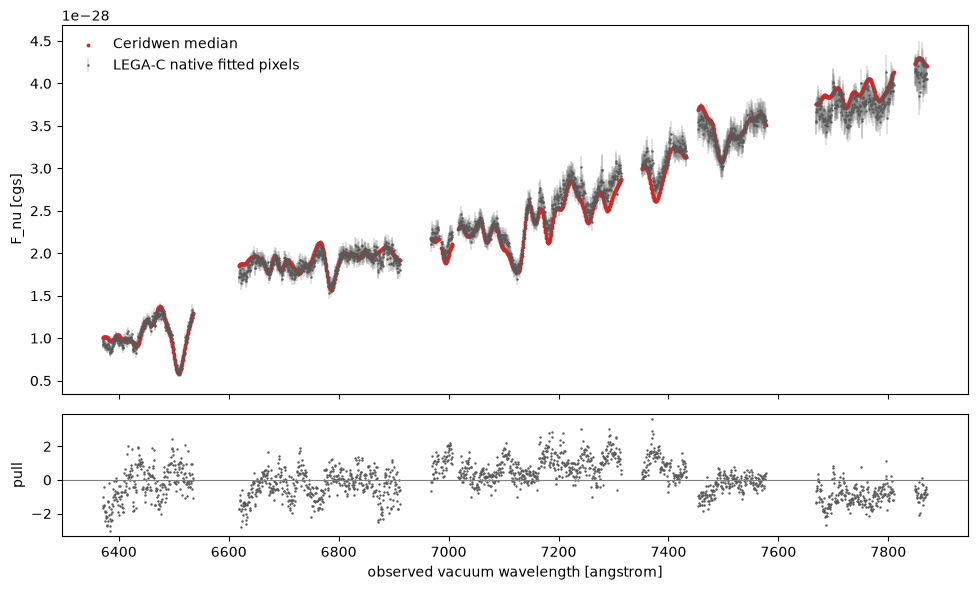

sampled calibration floor: 3.89%
spectrum chi2/bin: 1.02
post-hoc calibrated chi2/bin: 0.74
post-hoc Chebyshev coefficients: [ 0.50373652 -0.77378173 -0.4789594  -0.13730895]


In [12]:
def posterior_batch(samples, model, count):
    total = len(next(iter(samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch, indices


spectrum_prediction_batch, prediction_posterior_indices = posterior_batch(
    spectrum_posterior, spectrum_model, 200
)
spectrum_predictions = np.asarray(
    spectrum_model.predict_vmap(spectrum_prediction_batch)["spectrum"]
)
spec_q16, spec_q50, spec_q84 = np.percentile(
    spectrum_predictions, [16, 50, 84], axis=0
)
calibration_fraction = float(
    np.exp(np.median(np.asarray(spectrum_posterior["log_f_calib"])))
)
effective_uncertainty = np.hypot(
    spectrum_uncertainty, calibration_fraction * np.abs(spec_q50)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=effective_uncertainty[spectrum_mask],
    fmt=".",
    ms=1.5,
    elinewidth=0.25,
    color="0.35",
    label="LEGA-C native fitted pixels",
)
axes[0].scatter(
    spectrum_wave[spectrum_mask],
    spec_q50[spectrum_mask],
    color="tab:red",
    s=3,
    label="Ceridwen median",
)
axes[0].set(ylabel="F_nu [cgs]")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].scatter(
    spectrum_wave[spectrum_mask],
    (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
    / effective_uncertainty[spectrum_mask],
    s=3,
    linewidths=0,
    color="0.35",
)
axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
plt.tight_layout()
plt.show()

spectrum_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
        / effective_uncertainty[spectrum_mask]
    )
    ** 2
)
calibration_coefficients, calibrated_median = (
    spectrum_obs.fit_polynomial_calibration(spec_q50, order=3)
)
calibrated_effective_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(np.asarray(calibrated_median)),
)
calibrated_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - np.asarray(calibrated_median)[spectrum_mask])
        / calibrated_effective_uncertainty[spectrum_mask]
    )
    ** 2
)
print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")
print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
print(f"post-hoc calibrated chi2/bin: {calibrated_chi2 / spectrum_obs.ndof:.2f}")
print(f"post-hoc Chebyshev coefficients: {calibration_coefficients}")

## Full native-spectrum comparison

- project posterior draws across every native pixel
- mark the compact pixels used by the likelihood

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


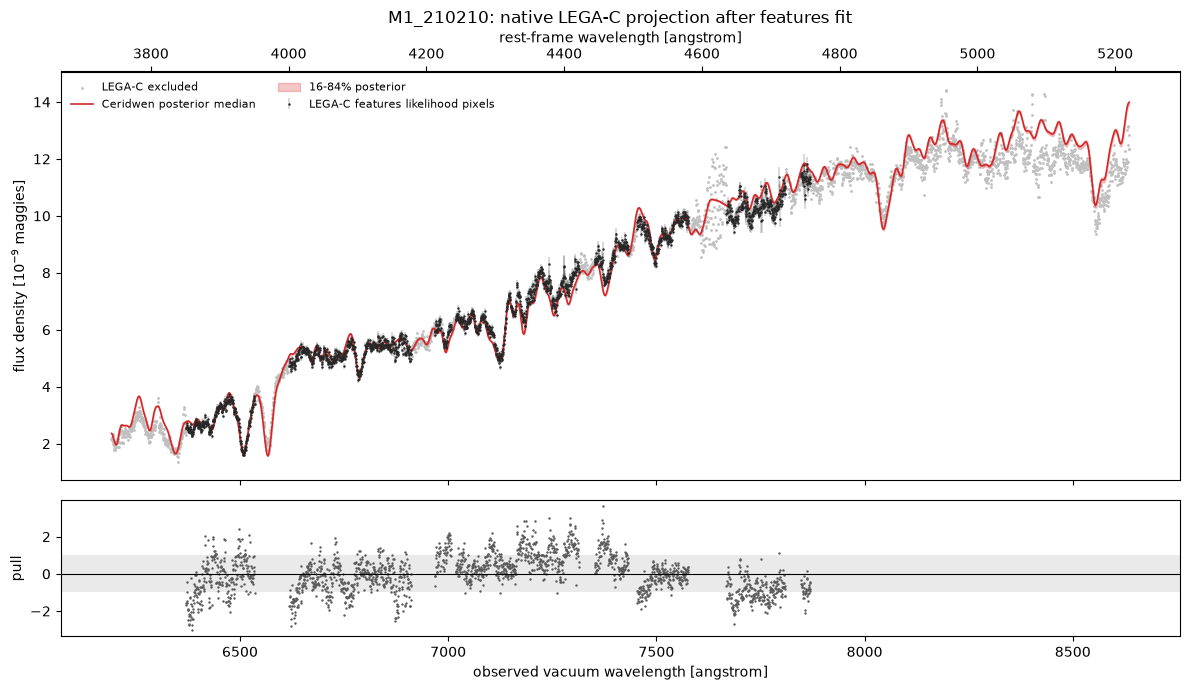

native valid pixels shown: 4053
full fitted pixels after exclusions: 3523
features likelihood pixels: 1924
full native projection is diagnostic only


In [13]:
CGS_FNU_PER_MAGGIE = 3631e-23
native_model, _, _ = make_model(
    native_spectrum_obs, free_redshift=False, sigma_losvd=0.0
)
native_prediction_batch, native_prediction_indices = posterior_batch(
    spectrum_posterior, native_model, 200
)
assert np.array_equal(native_prediction_indices, prediction_posterior_indices)
native_predictions = np.asarray(
    native_model.predict_vmap(native_prediction_batch)[native_spectrum_obs.name]
)
native_q16, native_q50, native_q84 = np.percentile(
    native_predictions, [16, 50, 84], axis=0
)
native_plot_flux = native_flux
native_plot_uncertainty = native_uncertainty
native_effective_uncertainty = np.hypot(
    native_plot_uncertainty,
    calibration_fraction * np.abs(native_q50),
)
native_excluded_mask = native_valid & ~fit_pixel_mask
native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].scatter(
    wave_vacuum[native_excluded_mask],
    native_plot_flux[native_excluded_mask] * native_plot_scale,
    s=4,
    color="0.75",
    linewidths=0,
    label="LEGA-C excluded",
    rasterized=True,
)
axes[0].errorbar(
    wave_vacuum[fit_pixel_mask],
    native_plot_flux[fit_pixel_mask] * native_plot_scale,
    yerr=native_plot_uncertainty[fit_pixel_mask] * native_plot_scale,
    fmt=".",
    ms=1.5,
    color="0.15",
    elinewidth=0.25,
    label=f"LEGA-C {SPECTRUM_MODE} likelihood pixels",
    rasterized=True,
)
axes[0].plot(
    wave_vacuum[native_valid],
    native_q50[native_valid] * native_plot_scale,
    color="tab:red",
    lw=1.2,
    label="Ceridwen posterior median",
)
axes[0].fill_between(
    wave_vacuum[native_valid],
    native_q16[native_valid] * native_plot_scale,
    native_q84[native_valid] * native_plot_scale,
    color="tab:red",
    alpha=0.25,
    label="16-84% posterior",
)
axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
axes[0].set_title(
    f"M1_210210: native LEGA-C projection after {SPECTRUM_MODE} fit"
)
axes[0].legend(frameon=False, ncol=2, fontsize=8)
axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].scatter(
    wave_vacuum[fit_pixel_mask],
    (native_plot_flux[fit_pixel_mask] - native_q50[fit_pixel_mask])
    / native_effective_uncertainty[fit_pixel_mask],
    color="0.35",
    s=3,
    linewidths=0,
    rasterized=True,
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="pull",
)
secondary_axis = axes[0].secondary_xaxis(
    "top",
    functions=(
        lambda observed: observed / (1 + z_catalog),
        lambda rest: rest * (1 + z_catalog),
    ),
)
secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
plt.tight_layout()
plt.show()

print(f"native valid pixels shown: {native_valid.sum()}")
print(f"full fitted pixels after exclusions: {native_fit_mask.sum()}")
print(f"{SPECTRUM_MODE} likelihood pixels: {fit_pixel_mask.sum()}")
print("full native projection is diagnostic only")

## 12. Recover the star-formation history and age

- translate sampled ratios into a mass-weighted age
- save fitted and derived arrays in machine-readable form

,parameter,median,minus,plus
0,logmass,11.592100,0.010538,0.010388
1,Z,-1.351525,0.031617,0.032228
2,afe,0.124849,0.011910,0.010839
3,diffuse_ta...,0.478687,0.017987,0.016449
4,fractional...,0.038925,0.000753,0.000764
5,mass-weigh...,2.838695,0.037474,0.050044


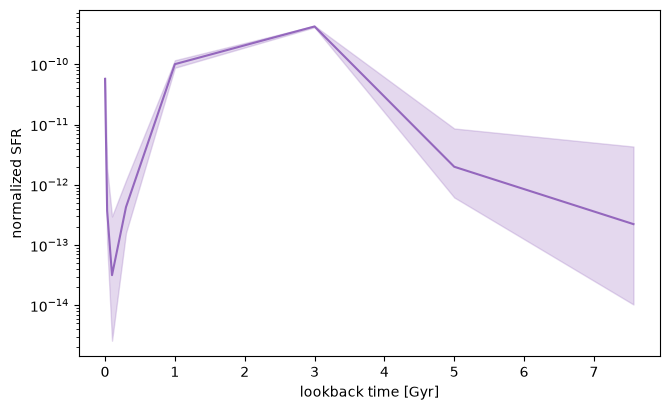

spectrum redshift fixed at 0.6542
spectrum velocity dispersion fixed at 259.5 km/s
spectrum logmass is a slit-aperture normalization


saved derived outputs: /workspace/notebooks/ceridwen_test_spectra_features_gpu-full_20260825T174826Z/ceridwen_derived_outputs.h5
notebook wall time: 10928.4 s


In [14]:
def derived_sfh(samples, count=400):
    total = len(samples["logsfr_ratios"])
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    histories = []
    ages = []
    for index in indices:
        ratios = np.asarray(samples["logsfr_ratios"])[index]
        history = np.asarray(
            logsfr_ratios_to_sfh(
                ratios,
                sfh_times_yr=lookback_template * 1e9,
            )
        )
        bin_mass = (
            0.5
            * (history[:-1] + history[1:])
            * np.diff(lookback_template)
            * 1e9
        )
        bin_age = 0.5 * (lookback_template[:-1] + lookback_template[1:])
        histories.append(history)
        ages.append(np.sum(bin_mass * bin_age) / np.sum(bin_mass))
    return np.asarray(histories), np.asarray(ages), indices


spectrum_histories, spectrum_ages, sfh_posterior_indices = derived_sfh(
    spectrum_posterior
)
summary_rows = []
for parameter in ["logmass", "Z", "afe", "diffuse_tau_kc"]:
    q16, q50, q84 = np.percentile(
        spectrum_posterior[parameter],
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": parameter,
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }
    )
q16, q50, q84 = np.percentile(
    np.exp(np.asarray(spectrum_posterior["log_f_calib"])),
    [16, 50, 84],
)
summary_rows.append(
    {
        "parameter": "fractional calibration floor",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
q16, q50, q84 = np.percentile(spectrum_ages, [16, 50, 84])
summary_rows.append(
    {
        "parameter": "mass-weighted age [Gyr]",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
summary_table = pd.DataFrame(summary_rows)
display(summary_table)

sfh_q16, sfh_q50, sfh_q84 = np.percentile(
    spectrum_histories, [16, 50, 84], axis=0
)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, sfh_q50, color="tab:purple")
ax.fill_between(
    lookback_template, sfh_q16, sfh_q84, color="tab:purple", alpha=0.25
)
ax.set(yscale="log", xlabel="lookback time [Gyr]", ylabel="normalized SFR")
plt.show()

print(f"spectrum redshift fixed at {z_catalog:.4f}")
print(f"spectrum velocity dispersion fixed at {sigma_star:.1f} km/s")
print("spectrum logmass is a slit-aperture normalization")

notebook_completed_at = datetime.now(UTC)
notebook_wall_time_s = time.perf_counter() - NOTEBOOK_START_TIME
derived_path = RESULT_DIR / "ceridwen_derived_outputs.h5"
string_dtype = h5py.string_dtype(encoding="utf-8")
with h5py.File(derived_path, "w") as derived:
    derived.attrs.update(
        {
            "spectrum_mode": SPECTRUM_MODE,
            "run_profile": RUN_PROFILE,
            "run_id": RUN_ID,
            "seed": SEED,
            "notebook_started_at_utc": NOTEBOOK_STARTED_AT.isoformat(),
            "notebook_completed_at_utc": notebook_completed_at.isoformat(),
            "notebook_wall_time_s": notebook_wall_time_s,
            "redshift": z_catalog,
            "velocity_dispersion_km_s": sigma_star,
            "compact_data_pixels": spectrum_obs.ndata,
            "likelihood_pixels": spectrum_obs.ndof,
            "native_valid_pixels": int(native_valid.sum()),
            "full_likelihood_pixels": int(native_fit_mask.sum()),
            "num_live": spectrum_settings["num_live"],
            "num_inner_steps": spectrum_settings["num_inner_steps"],
            "num_delete": spectrum_settings["num_delete"],
            "logZ_tol": spectrum_settings["logZ_tol"],
            "sampler_wall_time_s": spectrum_result.wall_time_s,
            "likelihood_calls": spectrum_result.n_likelihood_calls,
            "posterior_weight_ess": spectrum_weight_ess,
            "diagnostics_passed": spectrum_diagnostics_passed,
            "spectrum_chi2_per_pixel": spectrum_chi2 / spectrum_obs.ndof,
            "calibrated_chi2_per_pixel": calibrated_chi2 / spectrum_obs.ndof,
            "fractional_calibration_floor": calibration_fraction,
        }
    )

    posterior_group = derived.create_group("posterior")
    posterior_group.create_dataset(
        "normalized_weights", data=spectrum_weights, compression="gzip"
    )
    posterior_group.create_dataset(
        "resample_indices", data=posterior_resample_indices, compression="gzip"
    )
    equal_weight_group = posterior_group.create_group("equal_weight")
    for name, values in spectrum_posterior.items():
        equal_weight_group.create_dataset(name, data=values, compression="gzip")

    compact_group = derived.create_group("compact_spectrum")
    for name, values in {
        "wavelength_vacuum_angstrom": spectrum_wave,
        "flux_fnu_cgs": spectrum_flux,
        "uncertainty_fnu_cgs": spectrum_uncertainty,
        "likelihood_mask": spectrum_mask,
        "effective_uncertainty_fnu_cgs": effective_uncertainty,
        "initial_prediction_fnu_cgs": initial_prediction,
        "posterior_predictions_fnu_cgs": spectrum_predictions,
        "posterior_q16_fnu_cgs": spec_q16,
        "posterior_q50_fnu_cgs": spec_q50,
        "posterior_q84_fnu_cgs": spec_q84,
        "calibrated_median_fnu_cgs": np.asarray(calibrated_median),
        "calibrated_effective_uncertainty_fnu_cgs": (
            calibrated_effective_uncertainty
        ),
        "calibration_coefficients": calibration_coefficients,
        "prediction_posterior_indices": prediction_posterior_indices,
    }.items():
        compact_group.create_dataset(name, data=values, compression="gzip")

    native_group = derived.create_group("native_spectrum")
    for name, values in {
        "wavelength_air_angstrom": wave_air,
        "wavelength_vacuum_angstrom": wave_vacuum,
        "rest_wavelength_air_angstrom": rest_wave_air,
        "flux_fnu_cgs": native_flux,
        "uncertainty_fnu_cgs": native_uncertainty,
        "valid_mask": native_valid,
        "full_likelihood_mask": native_fit_mask,
        "feature_band_mask": feature_pixel_mask,
        "selected_likelihood_mask": fit_pixel_mask,
        "excluded_mask": native_excluded_mask,
        "effective_uncertainty_fnu_cgs": native_effective_uncertainty,
        "posterior_predictions_fnu_cgs": native_predictions,
        "posterior_q16_fnu_cgs": native_q16,
        "posterior_q50_fnu_cgs": native_q50,
        "posterior_q84_fnu_cgs": native_q84,
        "prediction_posterior_indices": native_prediction_indices,
    }.items():
        native_group.create_dataset(name, data=values, compression="gzip")

    sfh_group = derived.create_group("sfh")
    for name, values in {
        "lookback_time_gyr": lookback_template,
        "posterior_indices": sfh_posterior_indices,
        "normalized_sfr_histories": spectrum_histories,
        "mass_weighted_age_gyr": spectrum_ages,
        "q16_normalized_sfr": sfh_q16,
        "q50_normalized_sfr": sfh_q50,
        "q84_normalized_sfr": sfh_q84,
    }.items():
        sfh_group.create_dataset(name, data=values, compression="gzip")

    diagnostics_group = derived.create_group("diagnostics")
    diagnostics_group.create_dataset(
        "parameter",
        data=spectrum_diagnostics["parameter"].to_numpy(dtype=object),
        dtype=string_dtype,
    )
    diagnostics_group.create_dataset(
        "kl_posterior_prior",
        data=spectrum_diagnostics["KL posterior||prior"].to_numpy(),
    )

    summary_group = derived.create_group("summary")
    summary_group.create_dataset(
        "parameter",
        data=summary_table["parameter"].to_numpy(dtype=object),
        dtype=string_dtype,
    )
    for name in ["median", "minus", "plus"]:
        summary_group.create_dataset(name, data=summary_table[name].to_numpy())

print(f"saved derived outputs: {derived_path}")
print(f"notebook wall time: {notebook_wall_time_s:.1f} s")

## 13. Interpretation boundary

- fit native pixels using C3K_HR and LEGA-C resolution
- spectroscopy probes features within a limited rest-frame window
- compare posteriors and runtime, not evidence across modes
- failed sampling diagnostics make the posterior exploratory
- do not propagate this age into H(z) yet